In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_chord_diagram import chord_diagram

Pretty column names and colors:

In [20]:
COLUMN_NAME_MAP = {
    "croplands": "Croplands",
    "flooded": "Flooded",
    "forests_primary": "Primary forests",
    "forests_secondary": "Secondary forests",
    "grasslands": "Grasslands",
    "other": "Other",
    "pastures": "Pastures",
    "settlements": "Settlements",
    "shrublands": "Shrublands",
    "wetlands": "Wetlands",
}

_color_map_base = {
    "croplands": "#B8860B",
    "flooded": "#4169E1",
    "forests_primary": "#006400",
    "forests_secondary": "#228B22",
    "grasslands": "#90EE90",
    "other": "#9932CC",
    "pastures": "#FFD700",
    "settlements": "#808080",
    "shrublands": "#FFA07A",
    "wetlands": "#40E0D0",
}
COLUMN_COLOR_MAP = {
    COLUMN_NAME_MAP[key]: _color_map_base[key] for key in COLUMN_NAME_MAP
}

Make start (index) - end (columns) pivot table from transition table:

In [31]:
pivot = (
    pd.read_csv("./transition_table_2000_2020.csv")
    .set_index("start")
    .sort_index(axis=0)
    .sort_index(axis=1)
)
pivot.head(5)

,croplands,flooded,forests_mangroves,forests_primary,forests_secondary,grasslands,other,pastures,settlements,shrublands,wetlands
start,,,,,,,,,,,
croplands,2.796008e+08,1.840709e+05,0,0.000000e+00,9.142245e+07,2.107813e+07,2.465113e+06,1.454166e+07,7.927213e+07,9.323859e+07,5.693137e+05
flooded,1.078600e+05,3.736860e+06,0,0.000000e+00,1.115272e+05,4.850239e+03,6.456255e+03,2.422348e+03,2.776788e+05,2.237103e+05,5.712437e+05
forests_mangroves,0.000000e+00,0.000000e+00,0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
forests_primary,4.466946e+05,3.940759e+04,0,2.992317e+08,0.000000e+00,0.000000e+00,0.000000e+00,8.907647e+03,5.421217e+04,8.895904e+04,0.000000e+00
forests_secondary,6.979633e+07,2.443569e+05,0,0.000000e+00,1.329176e+09,5.502753e+06,1.645562e+06,1.165857e+07,6.978789e+07,7.137444e+07,1.288286e+06


**Optional:** Remove land use classes with an area smaller than a threshold:

In [32]:
area_thresh = 10e6  # 10 million m²

mask = (pivot.sum(axis=0) > area_thresh) & (pivot.sum(axis=1) > area_thresh)

wanted_idx = mask[mask].index

pivot = pivot.filter(wanted_idx, axis=0).filter(wanted_idx, axis=1)
pivot.head(5)

,croplands,forests_primary,forests_secondary,grasslands,other,pastures,settlements,shrublands
croplands,2.796008e+08,0.000000e+00,9.142245e+07,2.107813e+07,2.465113e+06,1.454166e+07,7.927213e+07,9.323859e+07
forests_primary,4.466946e+05,2.992317e+08,0.000000e+00,0.000000e+00,0.000000e+00,8.907647e+03,5.421217e+04,8.895904e+04
forests_secondary,6.979633e+07,0.000000e+00,1.329176e+09,5.502753e+06,1.645562e+06,1.165857e+07,6.978789e+07,7.137444e+07
grasslands,1.468267e+07,0.000000e+00,1.476411e+07,1.541519e+07,4.342143e+04,0.000000e+00,1.099022e+06,5.727639e+06
other,8.877861e+05,0.000000e+00,2.043834e+05,8.635426e+04,1.111134e+07,3.470467e+04,6.029218e+06,6.315045e+06


Convert to numpy array:

In [33]:
mat = pivot.to_numpy(copy=True)

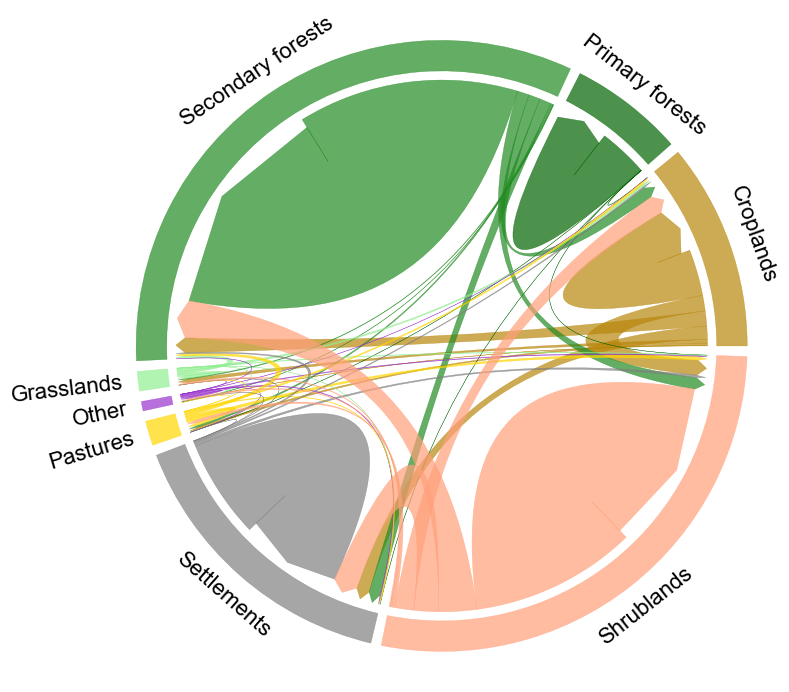

In [34]:
names = [COLUMN_NAME_MAP[c] for c in pivot.index]

fig, ax = plt.subplots(figsize=(8, 8))
diag = chord_diagram(
    mat,
    ax=ax,
    names=names,
    directed=True,
    rotate_names=[False, False, False, True, True, True, False, False],
    colors=[COLUMN_COLOR_MAP[c] for c in names],
    fontsize=16,
)

Remove self-transitions by setting the array diagonal to zero:

In [35]:
mat = pivot.to_numpy(copy=True)
np.fill_diagonal(mat, 0)

C:\Users\lain\Documents\AFOLU\.venv\Lib\site-packages\mpl_chord_diagram\utilities.py:167: RuntimeWarning: invalid value encountered in divide
  return (mat[i, :] / x[i]) * (end - start)


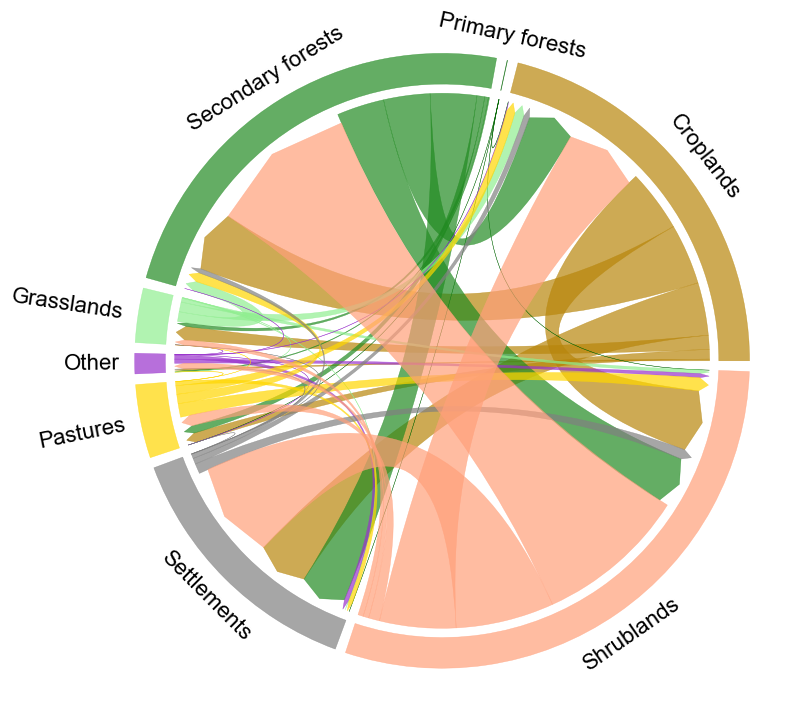

In [36]:
names = [COLUMN_NAME_MAP[c] for c in pivot.index]

fig, ax = plt.subplots(figsize=(8, 8))
diag = chord_diagram(
    mat,
    ax=ax,
    names=names,
    directed=True,
    rotate_names=[False, False, False, True, True, True, False, False],
    colors=[COLUMN_COLOR_MAP[c] for c in names],
    fontsize=16,
)